In [39]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
import shap
from lime.lime_tabular import LimeTabularExplainer
from itertools import cycle
from sklearn.neural_network import MLPClassifier
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler  
from sklearn.pipeline import make_pipeline

In [8]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("12 features - no imp.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)
# print(df_num.shape)
# print(df_num.columns)
# print(df_num['MHW_count'].value_counts())

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_count'] = df_numeric['mhw_count'].astype(str)

df_numeric.loc[df_numeric['mhw_count'].isin(['2', '3']), 'mhw_count'] = 2


print(df_numeric['mhw_count'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

shuffled_df_numeric = shuffled_df_numeric.rename({'sea surface temp':'SST', 'sea surface temp grad':'SST grad'}, axis = 1)

# Separate features (X) and labels (y) after shuffling
X_no = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y_no = shuffled_df_numeric['mhw_count']
X_no.shape, y_no.shape

mhw_count
0    3245
1     663
2     158
Name: count, dtype: int64


((4066, 11), (4066,))

In [12]:
nan = np.nan
imputer = KNNImputer(n_neighbors=9, weights="uniform")
imputed = imputer.fit_transform(shuffled_df_numeric)
imputed_df = pd.DataFrame(imputed, columns = shuffled_df_numeric.columns)
# Shuffle the DataFrame
shuffled_imp = shuffle(imputed_df, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_imp = shuffled_imp.drop(['mhw_count'], axis=1)
y_imp = shuffled_imp['mhw_count']
print(X_imp)

      ammonium  ammonium std   nitrite  nitrite std    nitrate      iron  \
2378  0.148010      0.081630  0.115258     0.061540  19.134088  0.000024   
2420  0.004013      0.005747  0.029337     0.039337   4.806092  0.000913   
1940  0.022734      0.006560  0.020362     0.023285   0.539207  0.000034   
1592  0.016536      0.002936  0.008397     0.001130   0.008090  0.001314   
2283  0.125834      0.169167  0.274189     0.185972   6.387228  0.000291   
...        ...           ...       ...          ...        ...       ...   
1130  0.006383      0.001038  0.018782     0.004922   0.089009  0.001242   
1294  0.011720      0.003029  0.072203     0.054703   1.106910  0.000011   
860   0.008846      0.000525  0.041098     0.004822   0.015244  0.001388   
3507  0.000621      0.001068  0.008424     0.006794   4.560707  0.001270   
3174  0.005640      0.000882  0.035153     0.021514   0.618738  0.001106   

      nitrate std  radiation 8.1  radiation 30  SST grad        SST  
2378     1.631620

C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ham

cross validation scores SVM: [0.91154791 0.88437884 0.88929889 0.9102091  0.90282903]
0.8997 accuracy with a standard deviation of 0.0110
Accuracy: 91.89%
SVM               precision    recall  f1-score   support

         0.0       0.95      0.98      0.97       650
         1.0       0.79      0.73      0.76       133
         2.0       0.65      0.42      0.51        31

    accuracy                           0.92       814
   macro avg       0.80      0.71      0.74       814
weighted avg       0.91      0.92      0.91       814

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000024C111AF190>


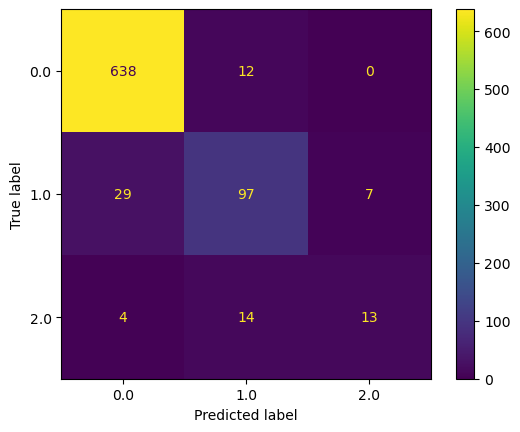

In [63]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)

model = MLPClassifier(solver='adam', alpha=0.0001, max_iter = 100,
                    hidden_layer_sizes=(100,), learning_rate_init = 0.001, random_state=1)
clf = make_pipeline(StandardScaler(), model)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
clf.predict_proba(X_test)

# Evaluate the model
cross_val_scores = cross_val_score(clf, X_imp, y_imp, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))

print('SVM', ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test))

cross validation scores SVM: [0.95454545 0.94710947 0.95694957 0.94710947 0.92742927]
0.9466 accuracy with a standard deviation of 0.0104
Accuracy: 95.70%
SVM               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       650
         1.0       0.85      0.90      0.88       133
         2.0       0.85      0.71      0.77        31

    accuracy                           0.96       814
   macro avg       0.89      0.86      0.88       814
weighted avg       0.96      0.96      0.96       814

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000024C1655FFD0>


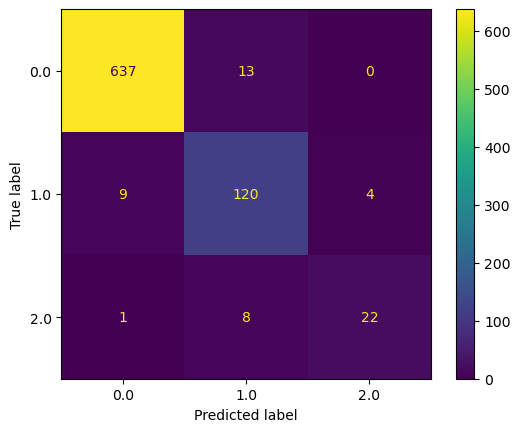

In [65]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)

model = MLPClassifier(solver='adam', alpha=0.0001, max_iter = 1000,
                    hidden_layer_sizes=(100,), learning_rate_init = 0.001, random_state=1)
clf = make_pipeline(StandardScaler(), model)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
clf.predict_proba(X_test)

# Evaluate the model
cross_val_scores = cross_val_score(clf, X_imp, y_imp, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))

print('SVM', ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test))

In [66]:
param_grid = [
     {'solver' : ['adam'],
      'alpha' : [0.0001, 0.001, 0.01, 0.1],
      'learning_rate_init' : [0.001, 0.01, 0.1],
      'max_iter' : [100, 500, 1000]
     }
]

grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_imp, y_imp)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ham

the best score was 0.8448072023717781
the best parameters were {'alpha': 0.0001, 'learning_rate_init': 0.001, 'max_iter': 500, 'solver': 'adam'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_learning_rate_init,param_max_iter,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.087090,0.059080,0.007559,0.006923,0.0001,0.001,100,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.001,...",0.821867,0.831488,0.829028,0.835178,0.836408,0.830794,0.005177,12
1,2.051236,0.921973,0.002216,0.001337,0.0001,0.001,500,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.001,...",0.858722,0.837638,0.849938,0.826568,0.851169,0.844807,0.011353,1
2,2.064623,0.888430,0.000401,0.000802,0.0001,0.001,1000,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.001,...",0.858722,0.837638,0.849938,0.826568,0.851169,0.844807,0.011353,1
3,0.678859,0.182287,0.005447,0.006324,0.0001,0.010,100,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.01, ...",0.807125,0.840098,0.835178,0.829028,0.826568,0.827600,0.011278,13
4,0.786655,0.343695,0.002005,0.001268,0.0001,0.010,500,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.01, ...",0.807125,0.840098,0.832718,0.829028,0.826568,0.827108,0.010986,14
5,0.711762,0.250014,0.006897,0.007435,0.0001,0.010,1000,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.01, ...",0.807125,0.840098,0.832718,0.829028,0.826568,0.827108,0.010986,14
6,0.482218,0.185929,0.002876,0.001715,0.0001,0.100,100,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.1, '...",0.797297,0.798278,0.798278,0.798278,0.798278,0.798082,0.000392,34
7,0.386362,0.127426,0.000801,0.000982,0.0001,0.100,500,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.1, '...",0.797297,0.798278,0.798278,0.798278,0.798278,0.798082,0.000392,34
8,0.449905,0.136533,0.002705,0.001598,0.0001,0.100,1000,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.1, '...",0.797297,0.798278,0.798278,0.798278,0.798278,0.798082,0.000392,34
9,1.182695,0.121023,0.007869,0.006890,0.0010,0.001,100,adam,"{'alpha': 0.001, 'learning_rate_init': 0.001, ...",0.823096,0.830258,0.829028,0.831488,0.847478,0.832270,0.008132,11


In [67]:
param_grid = [
     {'solver' : ['adam'],
      'alpha' : [0.0001],
      'learning_rate_init' : [0.001],
      'max_iter' : [300, 400, 500, 600, 700]
     }
]

grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_imp, y_imp)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


the best score was 0.8462832171319257
the best parameters were {'alpha': 0.0001, 'learning_rate_init': 0.001, 'max_iter': 300, 'solver': 'adam'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_learning_rate_init,param_max_iter,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.885548,0.668857,0.003551,0.006149,0.0001,0.001,300,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.001,...",0.858722,0.837638,0.857319,0.826568,0.851169,0.846283,0.012360,1
1,1.915070,0.799315,0.003161,0.006322,0.0001,0.001,400,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.001,...",0.858722,0.837638,0.849938,0.826568,0.851169,0.844807,0.011353,2
2,2.027038,0.841079,0.002815,0.002953,0.0001,0.001,500,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.001,...",0.858722,0.837638,0.849938,0.826568,0.851169,0.844807,0.011353,2
3,2.137019,0.918466,0.001954,0.001739,0.0001,0.001,600,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.001,...",0.858722,0.837638,0.849938,0.826568,0.851169,0.844807,0.011353,2
4,2.130353,1.039766,0.001604,0.001500,0.0001,0.001,700,adam,"{'alpha': 0.0001, 'learning_rate_init': 0.001,...",0.858722,0.837638,0.849938,0.826568,0.851169,0.844807,0.011353,2


cross validation scores SVM: [0.95331695 0.95202952 0.9495695  0.95694957 0.93357934]
0.9491 accuracy with a standard deviation of 0.0081
Accuracy: 96.56%
SVM               precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       650
         1.0       0.89      0.91      0.90       133
         2.0       0.88      0.90      0.89        31

    accuracy                           0.97       814
   macro avg       0.92      0.93      0.92       814
weighted avg       0.97      0.97      0.97       814

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000024C15EAAE00>


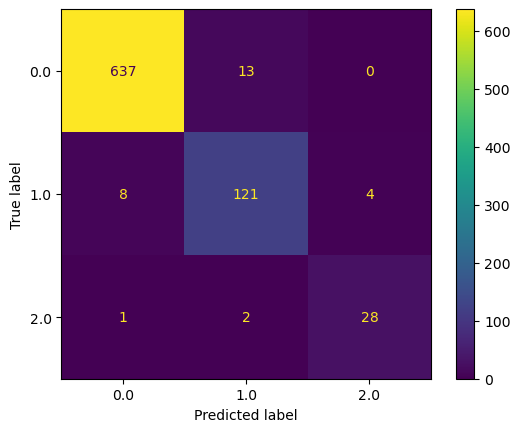

In [71]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)

model = MLPClassifier(solver='adam', alpha=0.0001, max_iter = 300,
                    hidden_layer_sizes=(100,), learning_rate_init = 0.01, random_state=1)
clf = make_pipeline(StandardScaler(), model)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
clf.predict_proba(X_test)

# Evaluate the model
cross_val_scores = cross_val_score(clf, X_imp, y_imp, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))

print('SVM', ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test))

## Best model - MLP

cross validation scores SVM: [0.95331695 0.95202952 0.9495695  0.95694957 0.93357934]
0.9491 accuracy with a standard deviation of 0.0081
Accuracy: 96.56%
SVM               precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       650
         1.0       0.89      0.91      0.90       133
         2.0       0.88      0.90      0.89        31

    accuracy                           0.97       814
   macro avg       0.92      0.93      0.92       814
weighted avg       0.97      0.97      0.97       814

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000024C1620AD40>


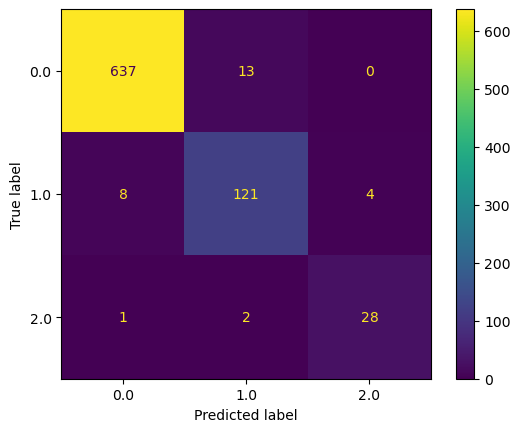

In [50]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)

model = MLPClassifier(solver='adam', alpha=0.0001, max_iter = 200,
                    hidden_layer_sizes=(100,), learning_rate_init = 0.01, random_state=1)
clf = make_pipeline(StandardScaler(), model)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
clf.predict_proba(X_test)

# Evaluate the model
cross_val_scores = cross_val_score(clf, X_imp, y_imp, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))

print('SVM', ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test))

In [55]:
param_grid = [
     {'solver' : ['adam'],
      'alpha' : [0.0001],
      'learning_rate_init' : [0.01],
      'max_iter' : [200],
      'beta_1' : [0.9, 0.8, 0.7],
      'beta_2' : [0.999, 0.995, 0.990]
     }
]

grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
the best score was 0.8164234904880064
the best parameters were {'alpha': 0.0001, 'beta_1': 0.7, 'beta_2': 0.995, 'learning_rate_init': 0.01, 'max_iter': 200, 'solver': 'adam'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_beta_1,param_beta_2,param_learning_rate_init,param_max_iter,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.270599,0.065809,0.005113,0.004020,0.0001,0.9,0.999,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.789555,0.811060,0.832308,0.815385,0.821538,0.813969,0.014143,3
1,0.293013,0.077616,0.002174,0.001289,0.0001,0.9,0.995,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.800307,0.807988,0.826154,0.813846,0.793846,0.808428,0.011156,6
2,0.302277,0.054690,0.001713,0.002539,0.0001,0.9,0.990,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.9, 'beta_2': 0.9...",0.809524,0.807988,0.772308,0.815385,0.829231,0.806887,0.018843,7
3,0.410696,0.165830,0.003794,0.006129,0.0001,0.8,0.999,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.8, 'beta_2': 0.9...",0.815668,0.803379,0.810769,0.807692,0.780000,0.803502,0.012416,9
4,0.288612,0.117847,0.002455,0.001438,0.0001,0.8,0.995,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.8, 'beta_2': 0.9...",0.815668,0.803379,0.813846,0.809231,0.830769,0.814579,0.009142,2
5,0.293277,0.128444,0.005220,0.005632,0.0001,0.8,0.990,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.8, 'beta_2': 0.9...",0.815668,0.807988,0.812308,0.807692,0.816923,0.812116,0.003805,5
6,0.293301,0.065951,0.002605,0.001202,0.0001,0.7,0.999,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.7, 'beta_2': 0.9...",0.815668,0.797235,0.813846,0.809231,0.826154,0.812427,0.009402,4
7,0.395563,0.139274,0.001001,0.001265,0.0001,0.7,0.995,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.7, 'beta_2': 0.9...",0.815668,0.807988,0.816923,0.812308,0.829231,0.816423,0.007113,1
8,0.371095,0.202891,0.002554,0.002154,0.0001,0.7,0.990,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.7, 'beta_2': 0.9...",0.818740,0.803379,0.804615,0.809231,0.784615,0.804116,0.011145,8


In [56]:
param_grid = [
     {'solver' : ['adam'],
      'alpha' : [0.0001],
      'learning_rate_init' : [0.01],
      'max_iter' : [200],
      'beta_1' : [0.7, 0.6, 0.5],
      'beta_2' : [0.995]
     }
]

grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
the best score was 0.8164234904880064
the best parameters were {'alpha': 0.0001, 'beta_1': 0.7, 'beta_2': 0.995, 'learning_rate_init': 0.01, 'max_iter': 200, 'solver': 'adam'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_beta_1,param_beta_2,param_learning_rate_init,param_max_iter,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.409145,0.151081,0.000802,0.000982,0.0001,0.7,0.995,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.7, 'beta_2': 0.9...",0.815668,0.807988,0.816923,0.812308,0.829231,0.816423,0.007113,1
1,0.373756,0.128333,0.003710,0.006069,0.0001,0.6,0.995,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.6, 'beta_2': 0.9...",0.815668,0.806452,0.816923,0.809231,0.758462,0.801347,0.021795,3
2,0.336867,0.082032,0.002284,0.002989,0.0001,0.5,0.995,0.01,200,adam,"{'alpha': 0.0001, 'beta_1': 0.5, 'beta_2': 0.9...",0.815668,0.809524,0.813846,0.810769,0.821538,0.814269,0.004237,2


cross validation scores SVM: [0.95454545 0.93480935 0.92619926 0.97170972 0.92250923]
0.9420 accuracy with a standard deviation of 0.0186
Accuracy: 93.37%
SVM               precision    recall  f1-score   support

         0.0       0.99      0.95      0.97       650
         1.0       0.74      0.92      0.82       133
         2.0       0.89      0.55      0.68        31

    accuracy                           0.93       814
   macro avg       0.87      0.81      0.82       814
weighted avg       0.94      0.93      0.93       814

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x0000024C15E53940>


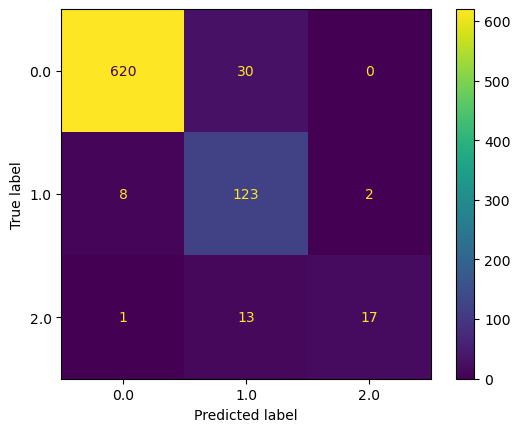

In [57]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)

model = MLPClassifier(solver='adam', alpha=0.0001, max_iter = 200,
                    hidden_layer_sizes=(100,), learning_rate_init = 0.01, beta_1 =0.7 , beta_2 =0.995 , random_state=1)
clf = make_pipeline(StandardScaler(), model)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
clf.predict_proba(X_test)

# Evaluate the model
cross_val_scores = cross_val_score(clf, X_imp, y_imp, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))

print('SVM', ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test))